# Step 09: Evaluation und Modellvergleich

Dieses Notebook dient nur der Evaluation. Es liest die vorhandenen Resultate aus `model_results/` und `trained_models/`, erzeugt Vergleichsgrafiken und zeigt Detailartefakte fuer das Modell, das in der Videopipeline am sinnvollsten ist. Training, Datenkonvertierung und Video-Blur bleiben in den Python-Skripten.


## Setup

Die aktuellste `evaluation_*.csv/json` wird automatisch verwendet. Falls ein bestimmter Lauf gezeigt werden soll, kann `EVAL_STEM` gesetzt werden.


In [1]:
from pathlib import Path
import csv
import json
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from IPython.display import Markdown, display, Image

ROOT = Path('/home/clemi/projekte/MIM')
RESULTS_DIR = ROOT / 'model_results'
PLOTS_DIR = RESULTS_DIR / 'plots'
YOLO_RUNS_DIR = ROOT / 'trained_models' / 'yolo_runs'

# None = aktuellster Evaluationslauf. Beispiel: 'evaluation_20260623_124037'
EVAL_STEM = None

if EVAL_STEM is None:
    eval_csv = sorted(RESULTS_DIR.glob('evaluation_*.csv'))[-1]
else:
    eval_csv = RESULTS_DIR / f'{EVAL_STEM}.csv'
eval_json = eval_csv.with_suffix('.json')

with eval_csv.open(newline='') as f:
    rows = list(csv.DictReader(f))
with eval_json.open() as f:
    eval_meta = json.load(f)

num_cols = ['precision', 'recall', 'f1', 'matched_faces', 'predictions', 'true_faces', 'ms_per_image', 'images_evaluated', 'images', 'detected_faces']
for row in rows:
    for col in num_cols:
        if col in row and row[col] != '':
            row[col] = float(row[col])
    row['images_evaluated'] = row.get('images_evaluated', row.get('images', eval_meta.get('args', {}).get('limit', 0)))
    row['matched_faces'] = row.get('matched_faces', row.get('detected_faces', 0))

print('Geladene Evaluation:', eval_csv)
print('Modelle:', len(rows))
print('Validierungsbilder:', int(rows[0]['images_evaluated']))
print('Ground-Truth-Faces:', int(rows[0]['true_faces']))


Geladene Evaluation: /home/clemi/projekte/MIM/model_results/evaluation_20260623_124037.csv
Modelle: 8
Validierungsbilder: 300
Ground-Truth-Faces: 3443


## Konkrete Zahlen zum Modellvergleich

Die Tabelle bleibt bewusst konkret: Sie ist der Zahlenstand, auf den sich die Praesentation beziehen kann. COCO-Baselines sind enthalten, aber getrennt markiert, weil sie nicht face-spezifisch trainiert wurden.


In [2]:
def family(model):
    m = Path(str(model)).name.lower()
    if 'baseline_pretrained_coco' in m:
        return 'COCO-Baseline'
    if 'yolo' in m:
        return 'YOLOv8m'
    if 'fasterrcnn' in m:
        return 'Faster R-CNN'
    if 'retinanet' in m:
        return 'RetinaNet'
    if 'fcos' in m:
        return 'FCOS'
    return 'Sonstiges'

def short_name(model):
    m = Path(str(model)).name
    if m.startswith('BASELINE_PRETRAINED_COCO_'):
        return 'COCO ' + m.replace('BASELINE_PRETRAINED_COCO_', '').upper()
    return m.replace('_widerface_rocm_bs2_', ' ').replace('_resnet50_fpn_rocm_bs2_', ' ')

def is_baseline(row):
    return str(row['model']).startswith('BASELINE_PRETRAINED_COCO_')

for row in rows:
    row['family'] = family(row['model'])
    row['display_name'] = short_name(row['model'])
    row['is_baseline'] = is_baseline(row)

trained = [r for r in rows if not r['is_baseline']]
baselines = [r for r in rows if r['is_baseline']]
trained_sorted = sorted(trained, key=lambda r: r['recall'], reverse=True)

header = ['Rang', 'Modell', 'Familie', 'Recall', 'Treffer', 'GT-Faces', 'Bilder', 'ms/Bild']
lines = ['|' + '|'.join(header) + '|', '|' + '|'.join(['---:', '---', '---', '---:', '---:', '---:', '---:', '---:']) + '|']
for idx, row in enumerate(trained_sorted, 1):
    lines.append(
        f"|{idx}|{row['display_name']}|{row['family']}|{row['recall']:.3f}|"
        f"{int(row['matched_faces'])}|{int(row['true_faces'])}|{int(row['images_evaluated'])}|{row['ms_per_image']:.1f}|"
    )
display(Markdown('\n'.join(lines)))

best_recall = trained_sorted[0]
fastest = min(trained, key=lambda r: r['ms_per_image'])
print('Recall-Sieger:', best_recall['display_name'], f"({best_recall['recall']:.3f})")
print('Schnellstes trainiertes Modell:', fastest['display_name'], f"({fastest['ms_per_image']:.1f} ms/Bild)")


|Rang|Modell|Familie|Recall|Treffer|GT-Faces|Bilder|ms/Bild|
|---:|---|---|---:|---:|---:|---:|---:|
|1|fcos red20_ep1.pth|FCOS|0.547|1884|3443|300|36.2|
|2|fasterrcnn red20_ep1.pth|Faster R-CNN|0.498|1714|3443|300|51.4|
|3|yolo_yolov8m red20_ep1.pt|YOLOv8m|0.406|1399|3443|300|43.7|
|4|retinanet red20_ep1.pth|RetinaNet|0.327|1125|3443|300|35.0|

Recall-Sieger: fcos red20_ep1.pth (0.547)
Schnellstes trainiertes Modell: retinanet red20_ep1.pth (35.0 ms/Bild)


## Vergleichsgrafiken

Die aussagekraeftigsten Grafiken sind Recall, Latenz, Precision/F1 und ein Speed-vs-Recall-Diagramm. Fuer Datenschutz ist Recall zentral, weil verpasste Gesichter kritischer sind als zu viele Blur-Boxen.


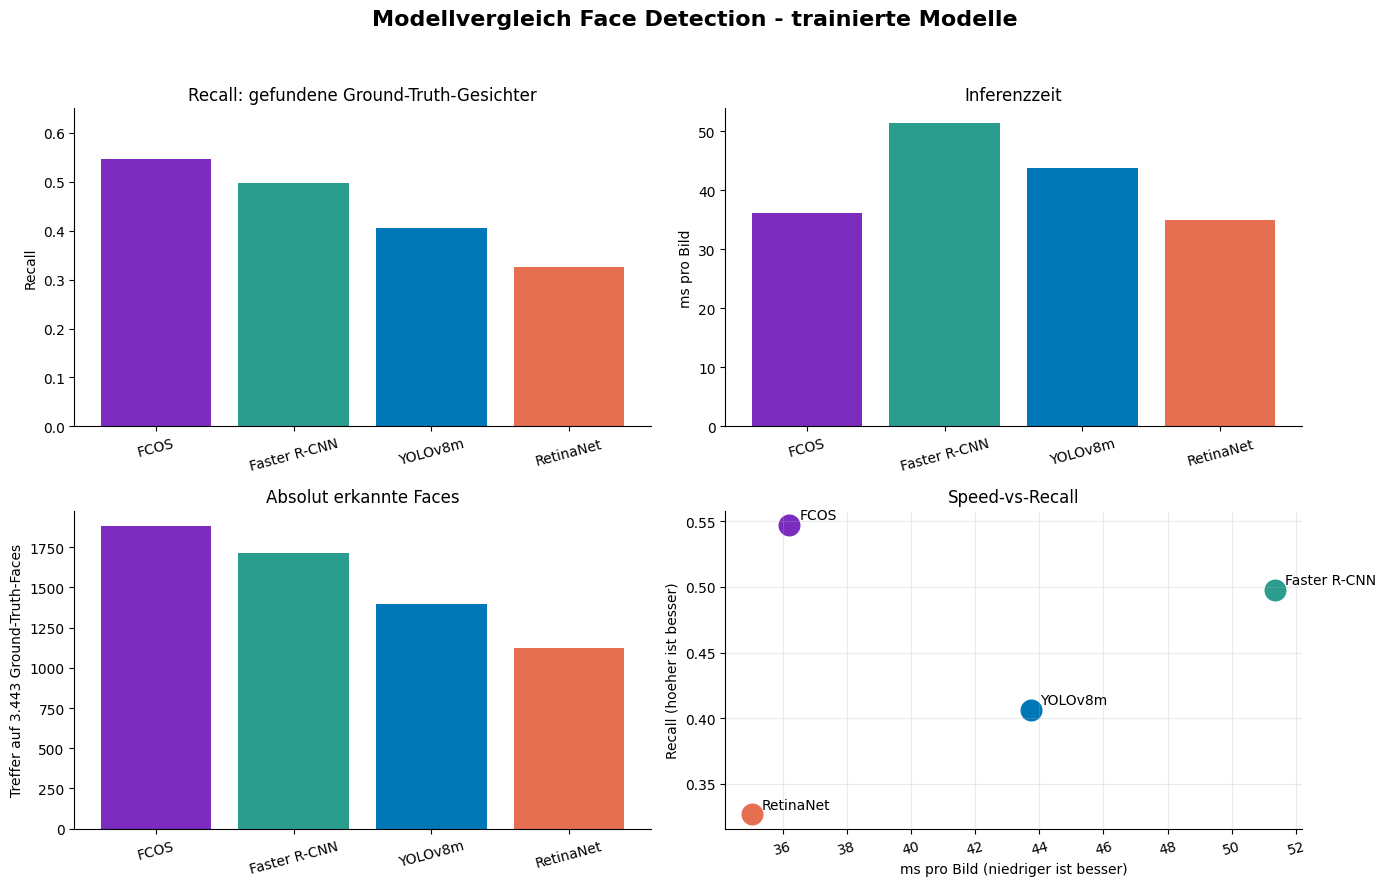

Gespeichert: /home/clemi/projekte/MIM/model_results/plots/step09_modellvergleich_hauptdiagramm_latest.png


In [3]:
colors = {
    'YOLOv8m': '#0077B6',
    'Faster R-CNN': '#2A9D8F',
    'RetinaNet': '#E76F51',
    'FCOS': '#7B2CBF',
    'COCO-Baseline': '#8D99AE',
}
plot_rows = trained_sorted
names = [r['family'] for r in plot_rows]
bar_colors = [colors.get(r['family'], '#555555') for r in plot_rows]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Modellvergleich Face Detection - trainierte Modelle', fontsize=16, fontweight='bold')

axes[0, 0].bar(names, [r['recall'] for r in plot_rows], color=bar_colors)
axes[0, 0].set_title('Recall: gefundene Ground-Truth-Gesichter')
axes[0, 0].set_ylim(0, max(0.65, max(r['recall'] for r in plot_rows) + 0.08))
axes[0, 0].set_ylabel('Recall')

axes[0, 1].bar(names, [r['ms_per_image'] for r in plot_rows], color=bar_colors)
axes[0, 1].set_title('Inferenzzeit')
axes[0, 1].set_ylabel('ms pro Bild')

axes[1, 0].bar(names, [r['matched_faces'] for r in plot_rows], color=bar_colors)
axes[1, 0].set_title('Absolut erkannte Faces')
axes[1, 0].set_ylabel('Treffer auf 3.443 Ground-Truth-Faces')

for r in plot_rows:
    axes[1, 1].scatter(r['ms_per_image'], r['recall'], s=220, color=colors.get(r['family'], '#555555'), label=r['family'])
    axes[1, 1].annotate(r['family'], (r['ms_per_image'], r['recall']), xytext=(7, 4), textcoords='offset points')
axes[1, 1].set_title('Speed-vs-Recall')
axes[1, 1].set_xlabel('ms pro Bild (niedriger ist besser)')
axes[1, 1].set_ylabel('Recall (hoeher ist besser)')
axes[1, 1].grid(True, alpha=0.25)

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=15)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout(rect=(0, 0, 1, 0.95))
out = PLOTS_DIR / 'step09_modellvergleich_hauptdiagramm_latest.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Gespeichert:', out)


## Face-Finetuning gegen COCO-Baselines

Dieser Vergleich zeigt, warum ein COCO-vortrainiertes Objektmodell nicht ausreicht: Ohne Face-Finetuning liegen die Trefferquoten deutlich unter den trainierten Face-Modellen.


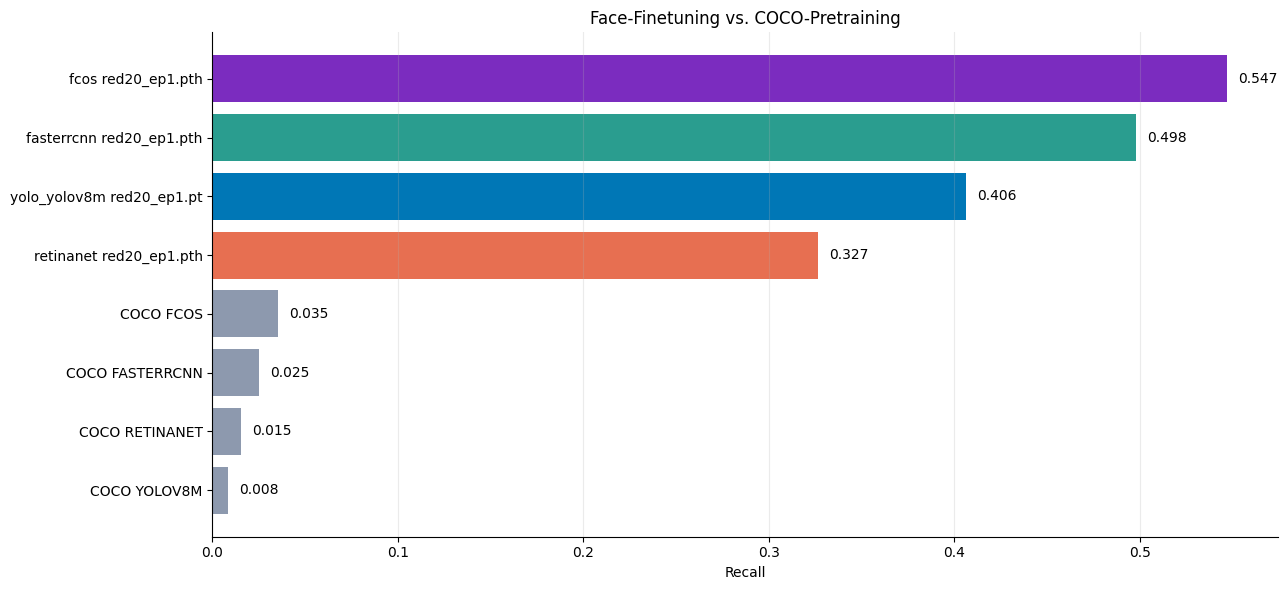

Gespeichert: /home/clemi/projekte/MIM/model_results/plots/step09_coco_baselines_vs_finetuning_latest.png


In [4]:
all_sorted = sorted(rows, key=lambda r: r['recall'], reverse=True)
labels = [r['display_name'] for r in all_sorted]
fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(labels, [r['recall'] for r in all_sorted], color=[colors.get(r['family'], '#555555') for r in all_sorted])
ax.invert_yaxis()
ax.set_xlabel('Recall')
ax.set_title('Face-Finetuning vs. COCO-Pretraining')
ax.grid(axis='x', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
for i, r in enumerate(all_sorted):
    ax.text(r['recall'] + 0.006, i, f"{r['recall']:.3f}", va='center')
plt.tight_layout()
out = PLOTS_DIR / 'step09_coco_baselines_vs_finetuning_latest.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Gespeichert:', out)


## Lernkurven und Model Results

Die Torchvision-Skripte schreiben Trainingsverluste nach `model_results/training_history_*.csv`. YOLO schreibt `results.csv` und `results.png` in den jeweiligen Run-Ordner. Beim aktuellen Red20/ep1-Lauf sind die Kurven kurz, aber sie dokumentieren den vergleichbaren Smoke-/Benchmark-Lauf.


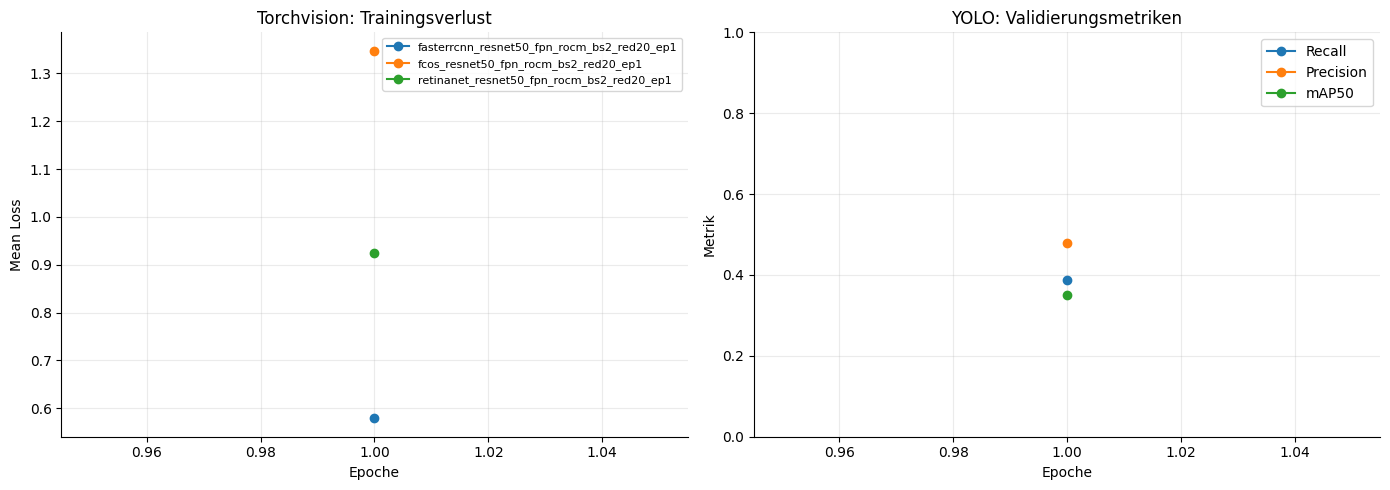

Gespeichert: /home/clemi/projekte/MIM/model_results/plots/step09_lernkurven_loss_accuracy_proxy_latest.png


In [5]:
def read_csv(path):
    with path.open(newline='') as f:
        data = list(csv.DictReader(f))
    for row in data:
        for k, v in list(row.items()):
            try:
                row[k] = float(v)
            except Exception:
                pass
    return data

history_files = sorted(RESULTS_DIR.glob('training_history_*red20_ep1_*.csv'))
yolo_run = YOLO_RUNS_DIR / 'yolo_yolov8m_widerface_rocm_bs2_red20_ep1'
yolo_results = yolo_run / 'results.csv'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for path in history_files:
    hist = read_csv(path)
    if not hist:
        continue
    label = path.name.replace('training_history_', '').split('_2026')[0]
    axes[0].plot([r.get('epoch', i + 1) for i, r in enumerate(hist)], [r.get('mean_loss') for r in hist], marker='o', label=label)
axes[0].set_title('Torchvision: Trainingsverlust')
axes[0].set_xlabel('Epoche')
axes[0].set_ylabel('Mean Loss')
axes[0].grid(True, alpha=0.25)
axes[0].legend(fontsize=8)

if yolo_results.exists():
    yhist = read_csv(yolo_results)
    # Spaltennamen kommen von Ultralytics teilweise mit fuehrenden Leerzeichen.
    cleaned = [{k.strip(): v for k, v in row.items()} for row in yhist]
    epochs = [r.get('epoch', i + 1) for i, r in enumerate(cleaned)]
    for col, label in [('metrics/recall(B)', 'Recall'), ('metrics/precision(B)', 'Precision'), ('metrics/mAP50(B)', 'mAP50')]:
        vals = [r.get(col) for r in cleaned if col in r]
        if vals:
            axes[1].plot(epochs[:len(vals)], vals, marker='o', label=label)
axes[1].set_title('YOLO: Validierungsmetriken')
axes[1].set_xlabel('Epoche')
axes[1].set_ylabel('Metrik')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.25)
axes[1].legend()

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
out = PLOTS_DIR / 'step09_lernkurven_loss_accuracy_proxy_latest.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Gespeichert:', out)


## Aus dem Evaluationsskript uebernommene Grafiken

Diese Grafiken wurden direkt von `step06_evaluate_models.py` erzeugt und sind fuer die Praesentation die kompaktesten Visualisierungen.


**dataset_train_vs_val_20260623_124037.png**

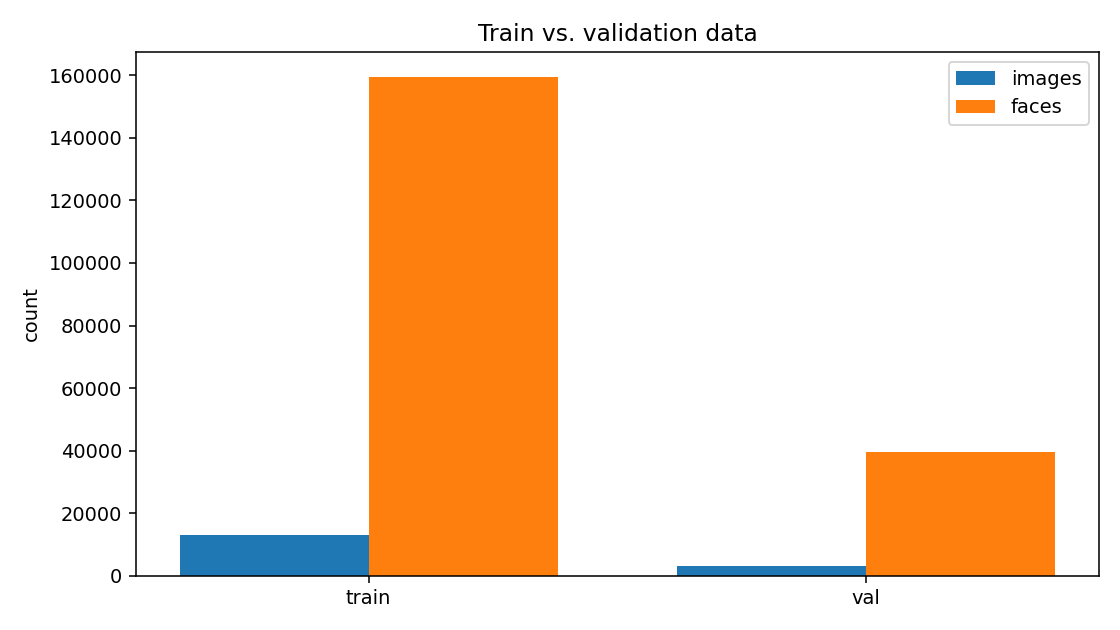

**validation_recall_20260623_124037.png**

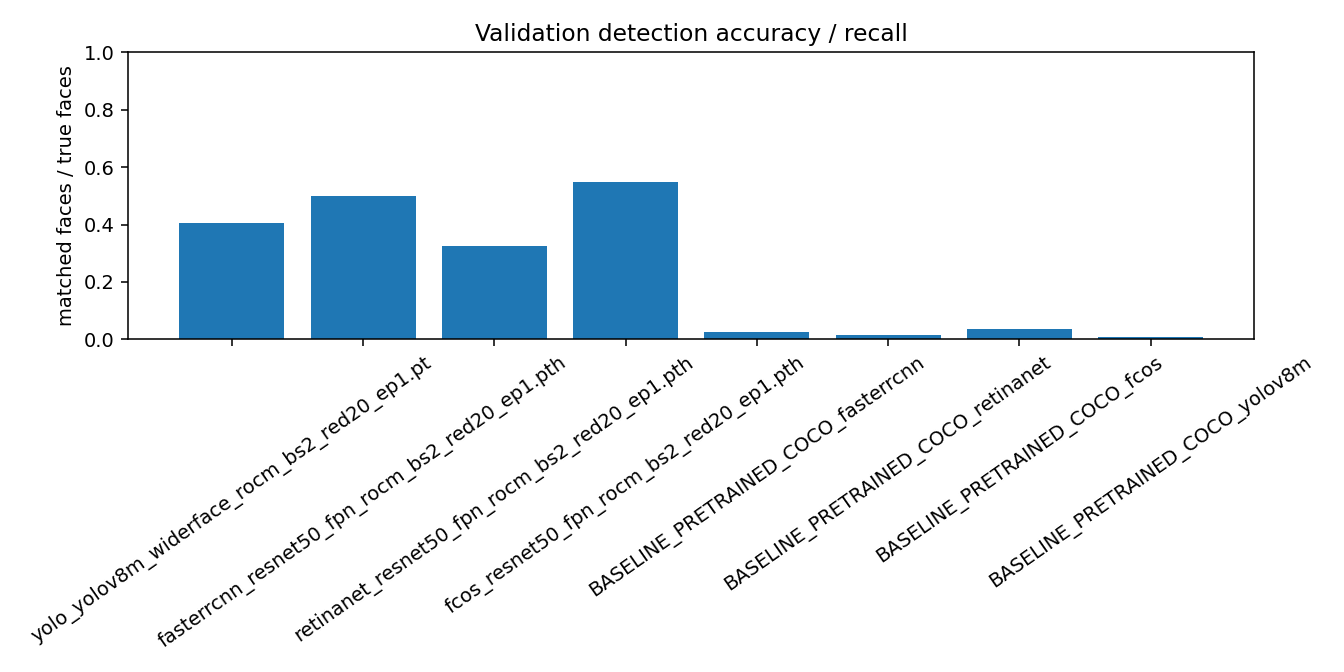

**validation_latency_20260623_124037.png**

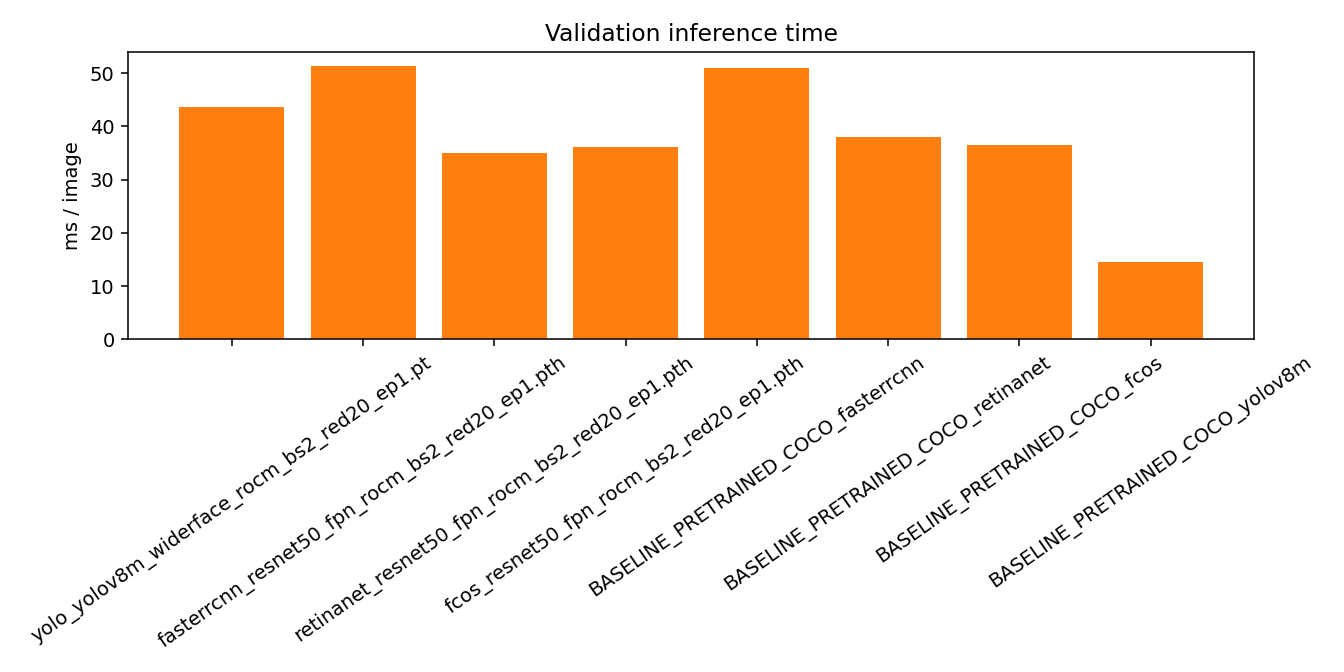

**threshold_sweep_20260623_124037.png**

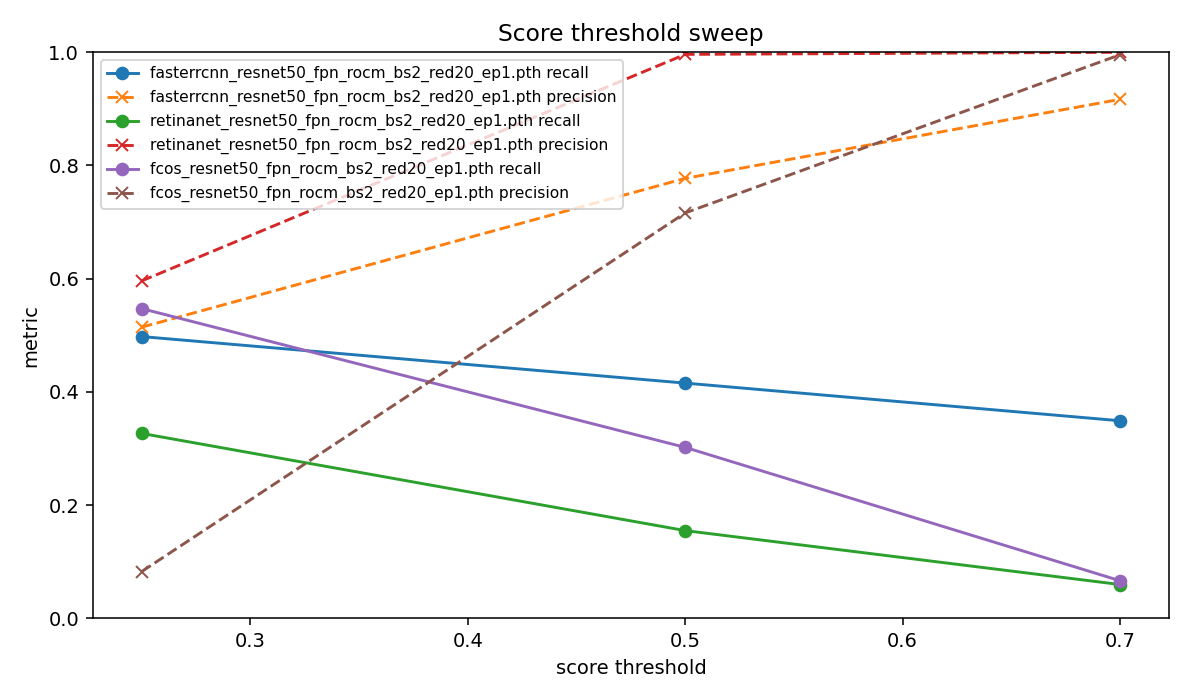

In [6]:
stem = eval_csv.stem.replace('evaluation_', '')
plot_names = [
    f'dataset_train_vs_val_{stem}.png',
    f'validation_recall_{stem}.png',
    f'validation_latency_{stem}.png',
    f'threshold_sweep_{stem}.png',
]
for name in plot_names:
    path = PLOTS_DIR / name
    if path.exists():
        display(Markdown(f'**{name}**'))
        display(Image(filename=str(path)))
    else:
        print('Fehlt:', path)


## Detailgrafiken fuer YOLO als Video-Pipeline-Modell

Im aktuellen Red20/ep1-Vergleich gewinnt FCOS beim Recall. Fuer die Video-Anonymisierung bleibt YOLO trotzdem besonders relevant, weil Ultralytics Inferenz, Thresholding, Ergebnisplots und spaetere Tracking-Ansaetze direkt in einer praxistauglichen Pipeline zusammenbringt. Deshalb werden hier die YOLO-Model-Results und die Confusion Matrix gezeigt.


YOLO Run: /home/clemi/projekte/MIM/trained_models/yolo_runs/yolo_yolov8m_widerface_rocm_bs2_red20_ep1


**results.png**

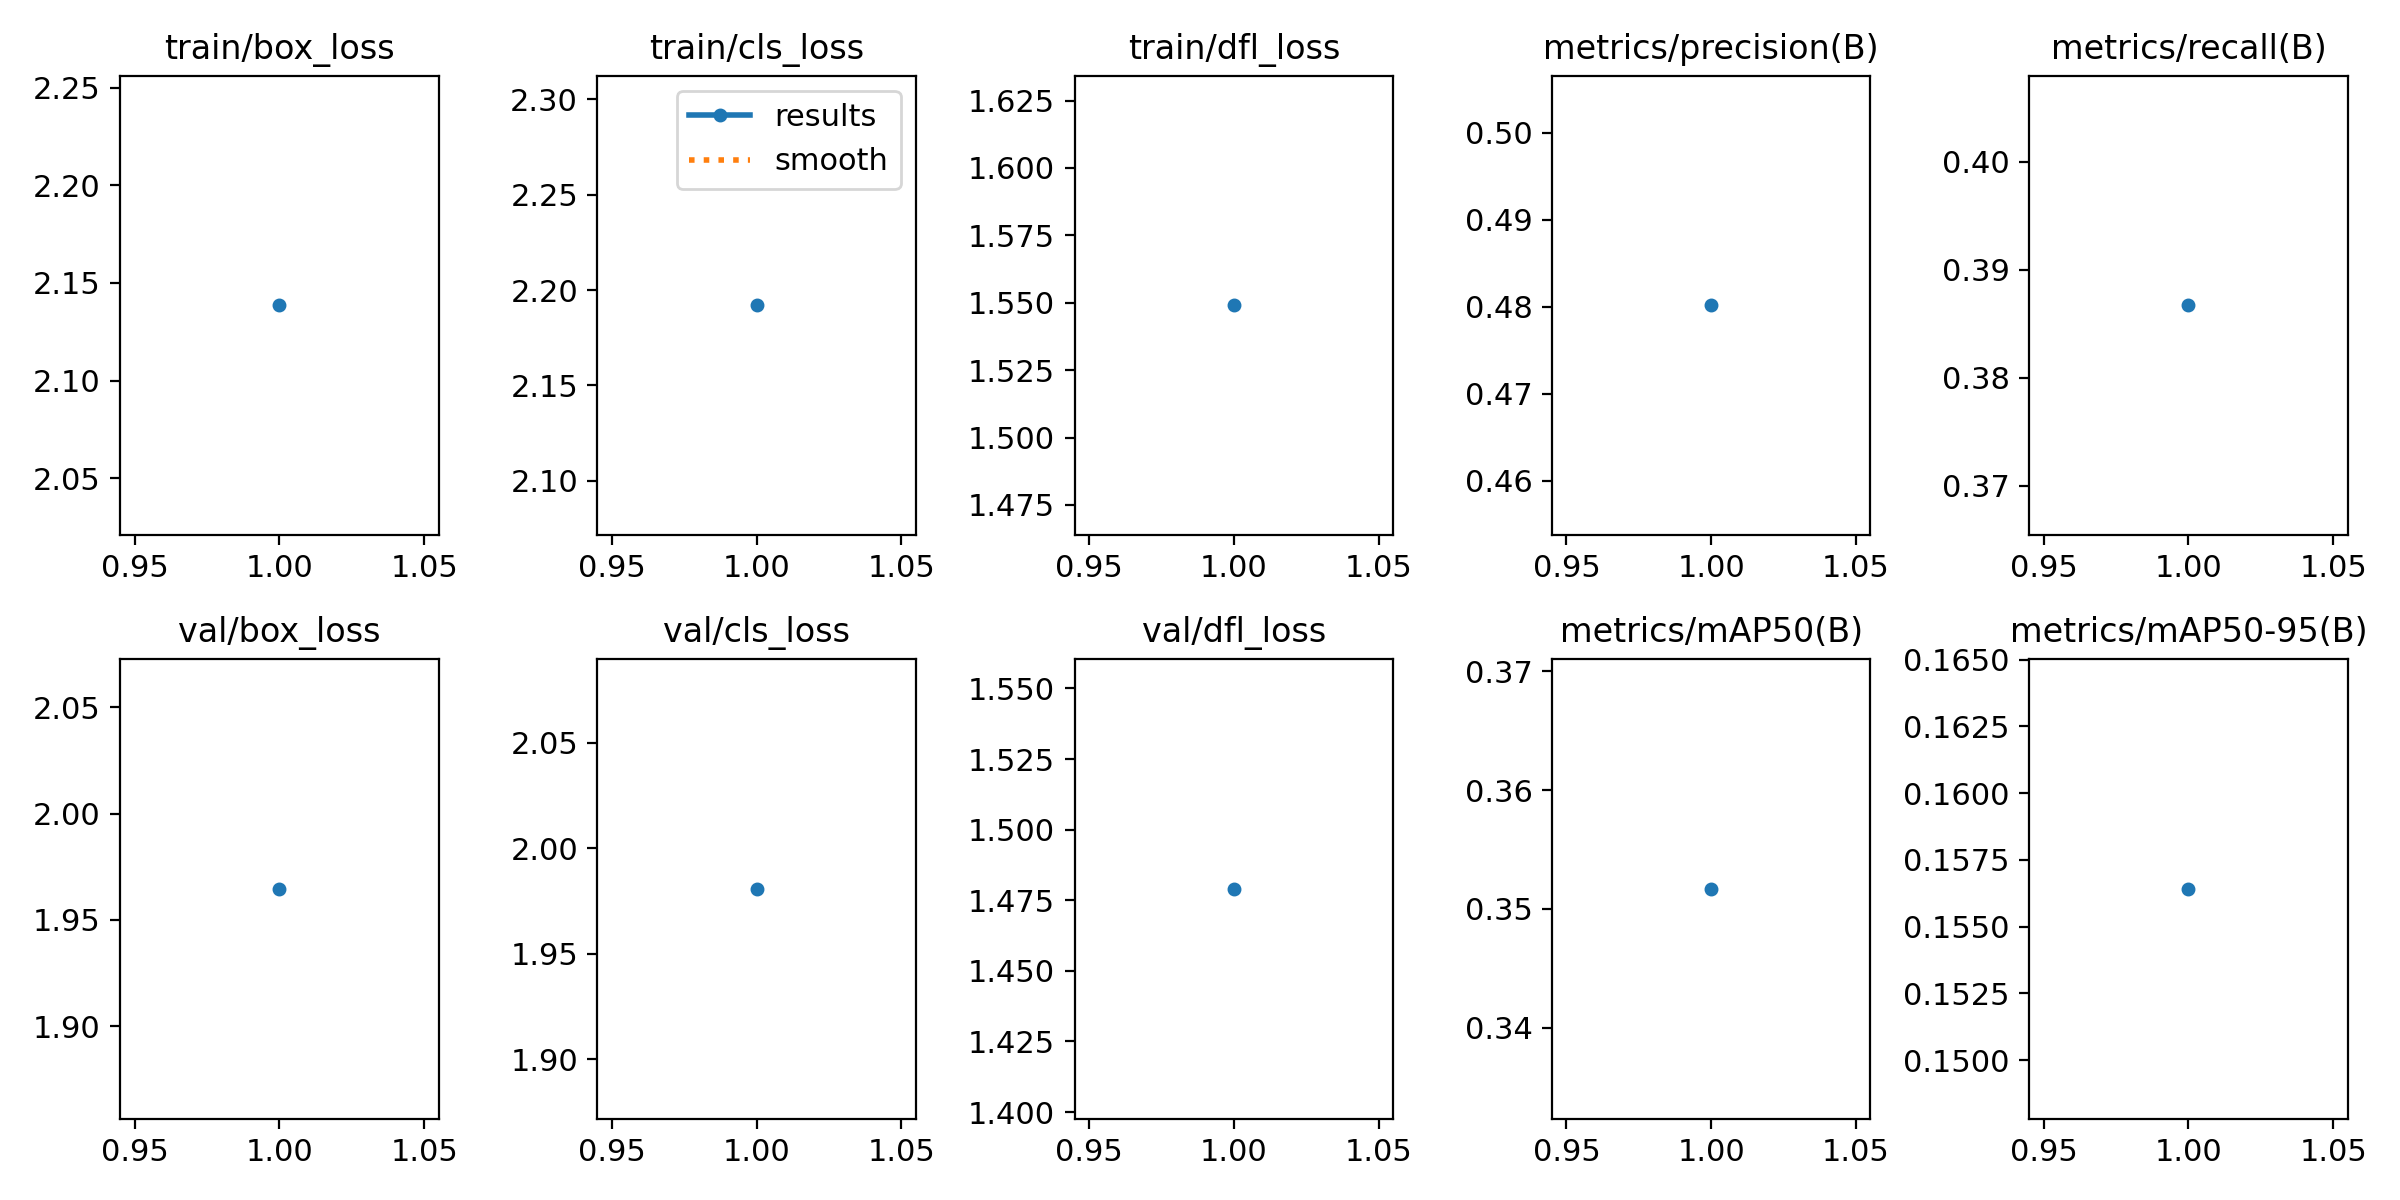

**confusion_matrix.png**

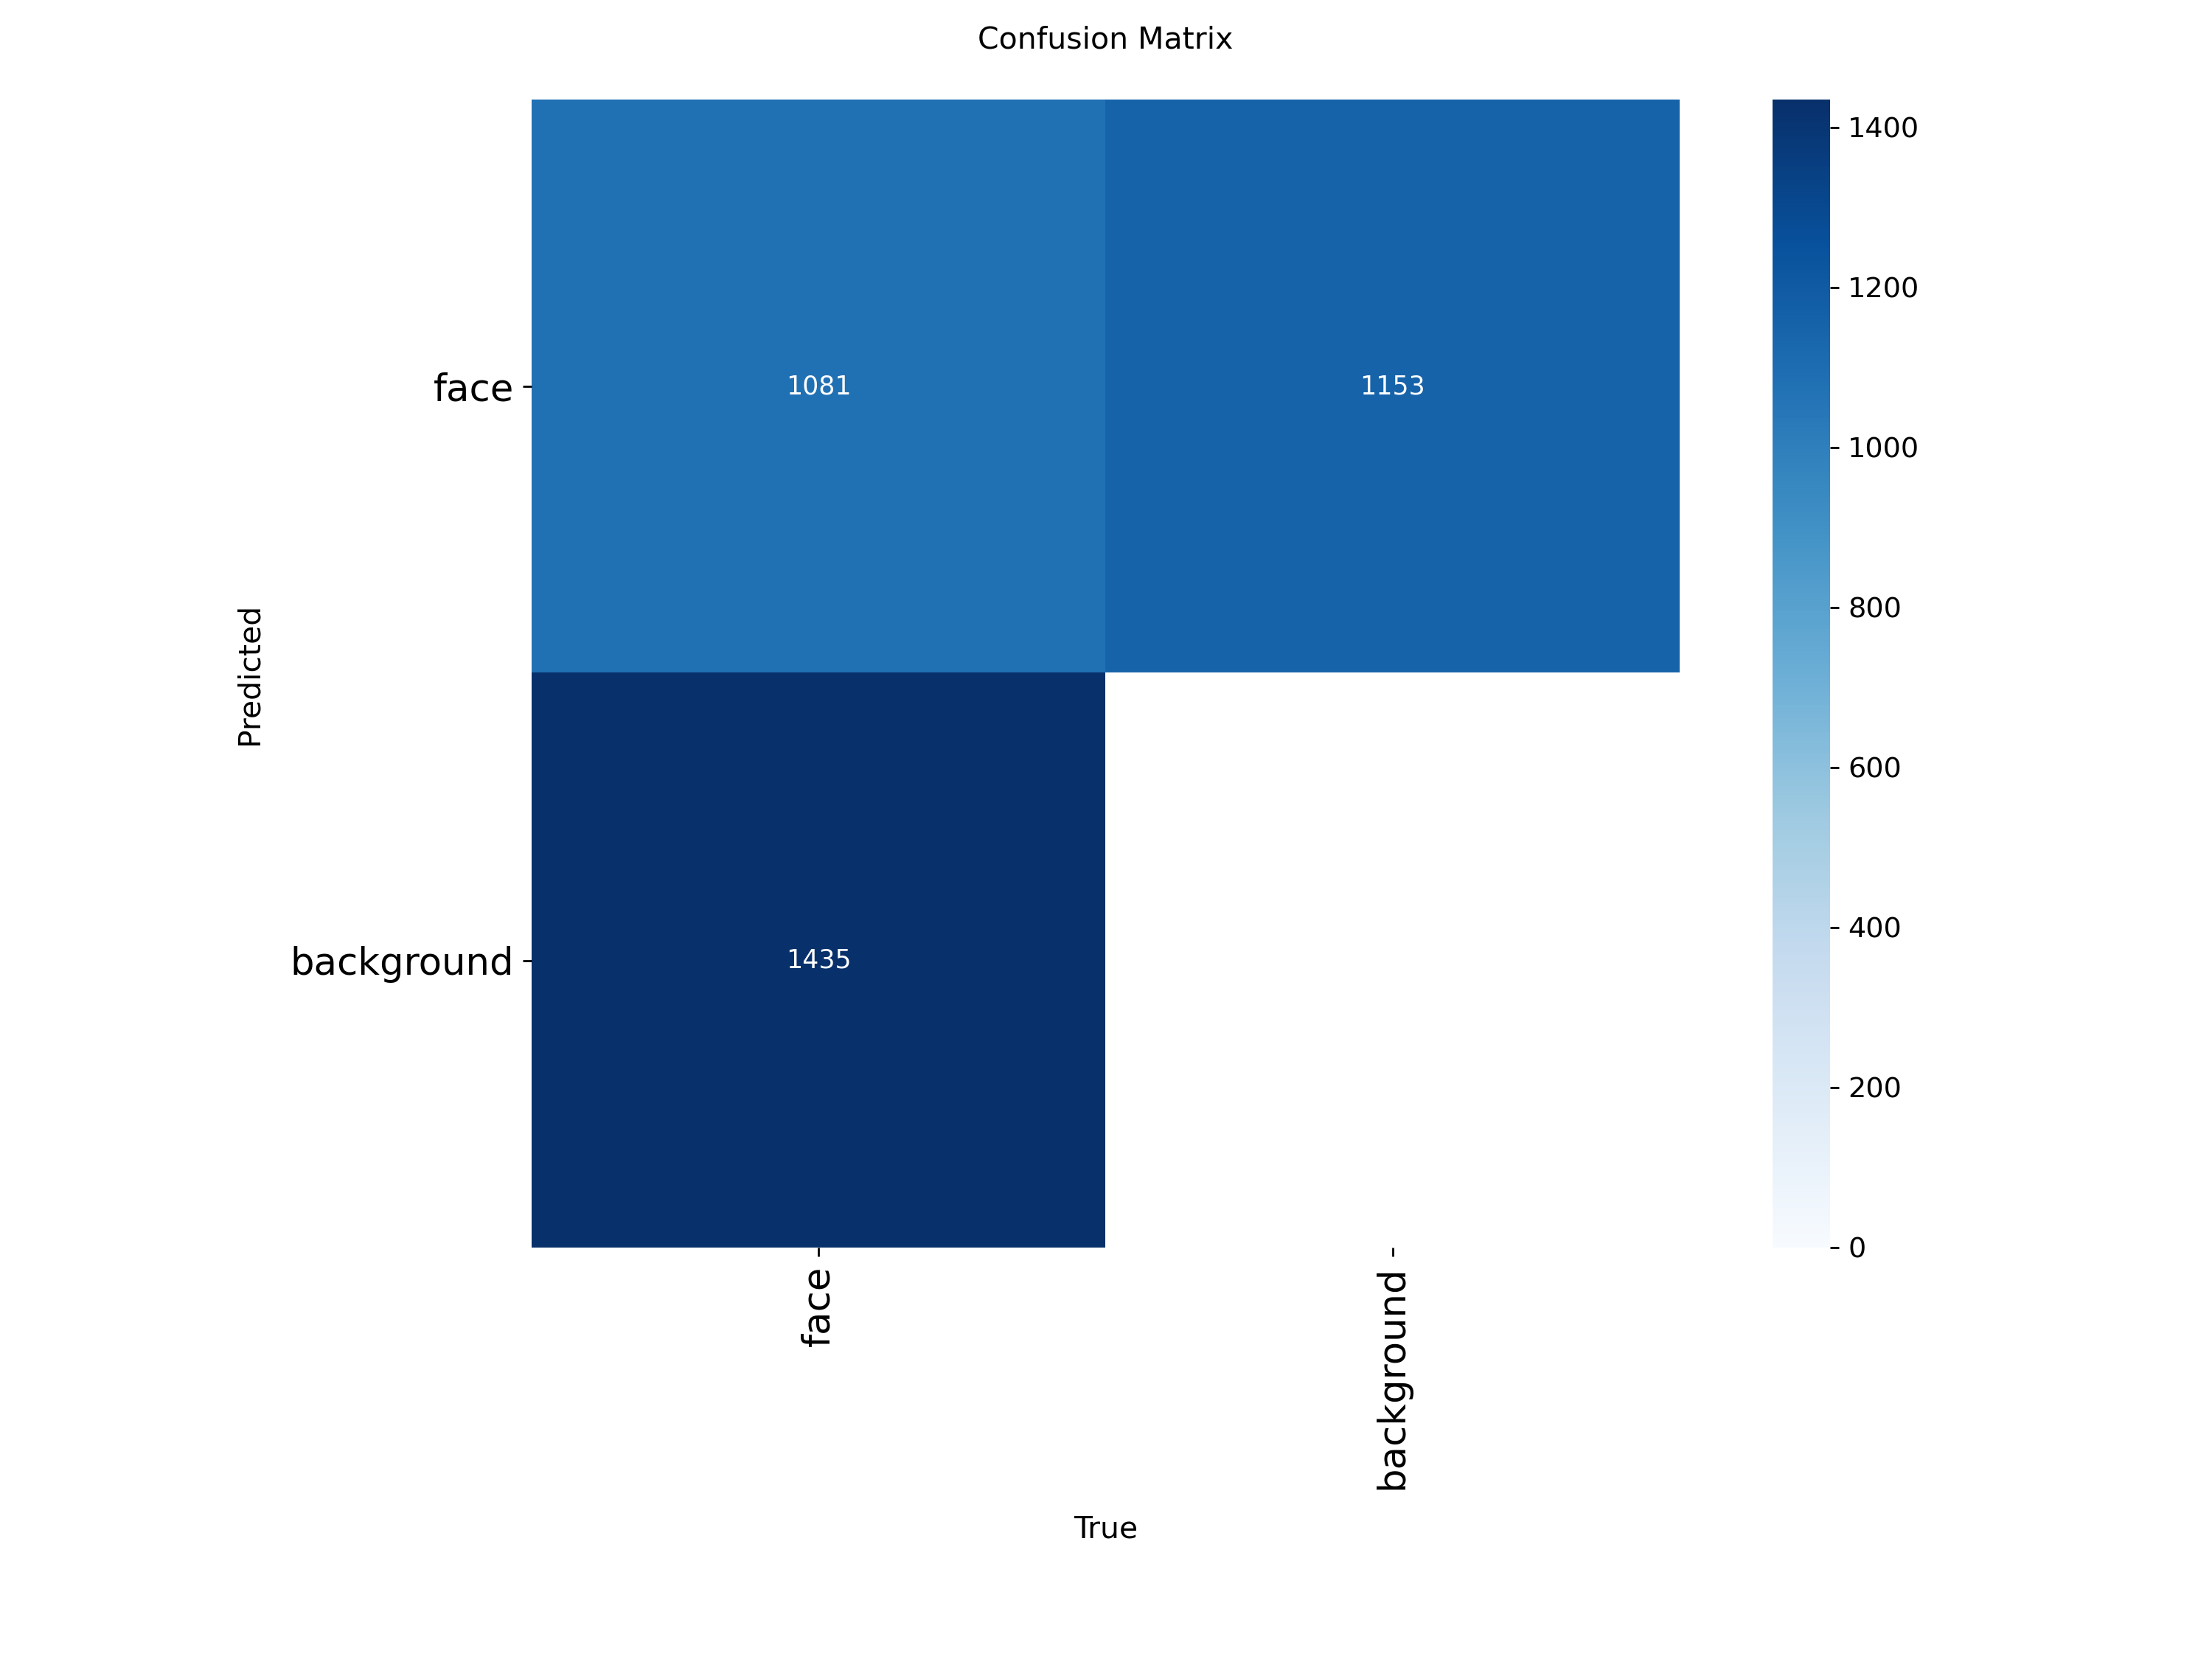

**confusion_matrix_normalized.png**

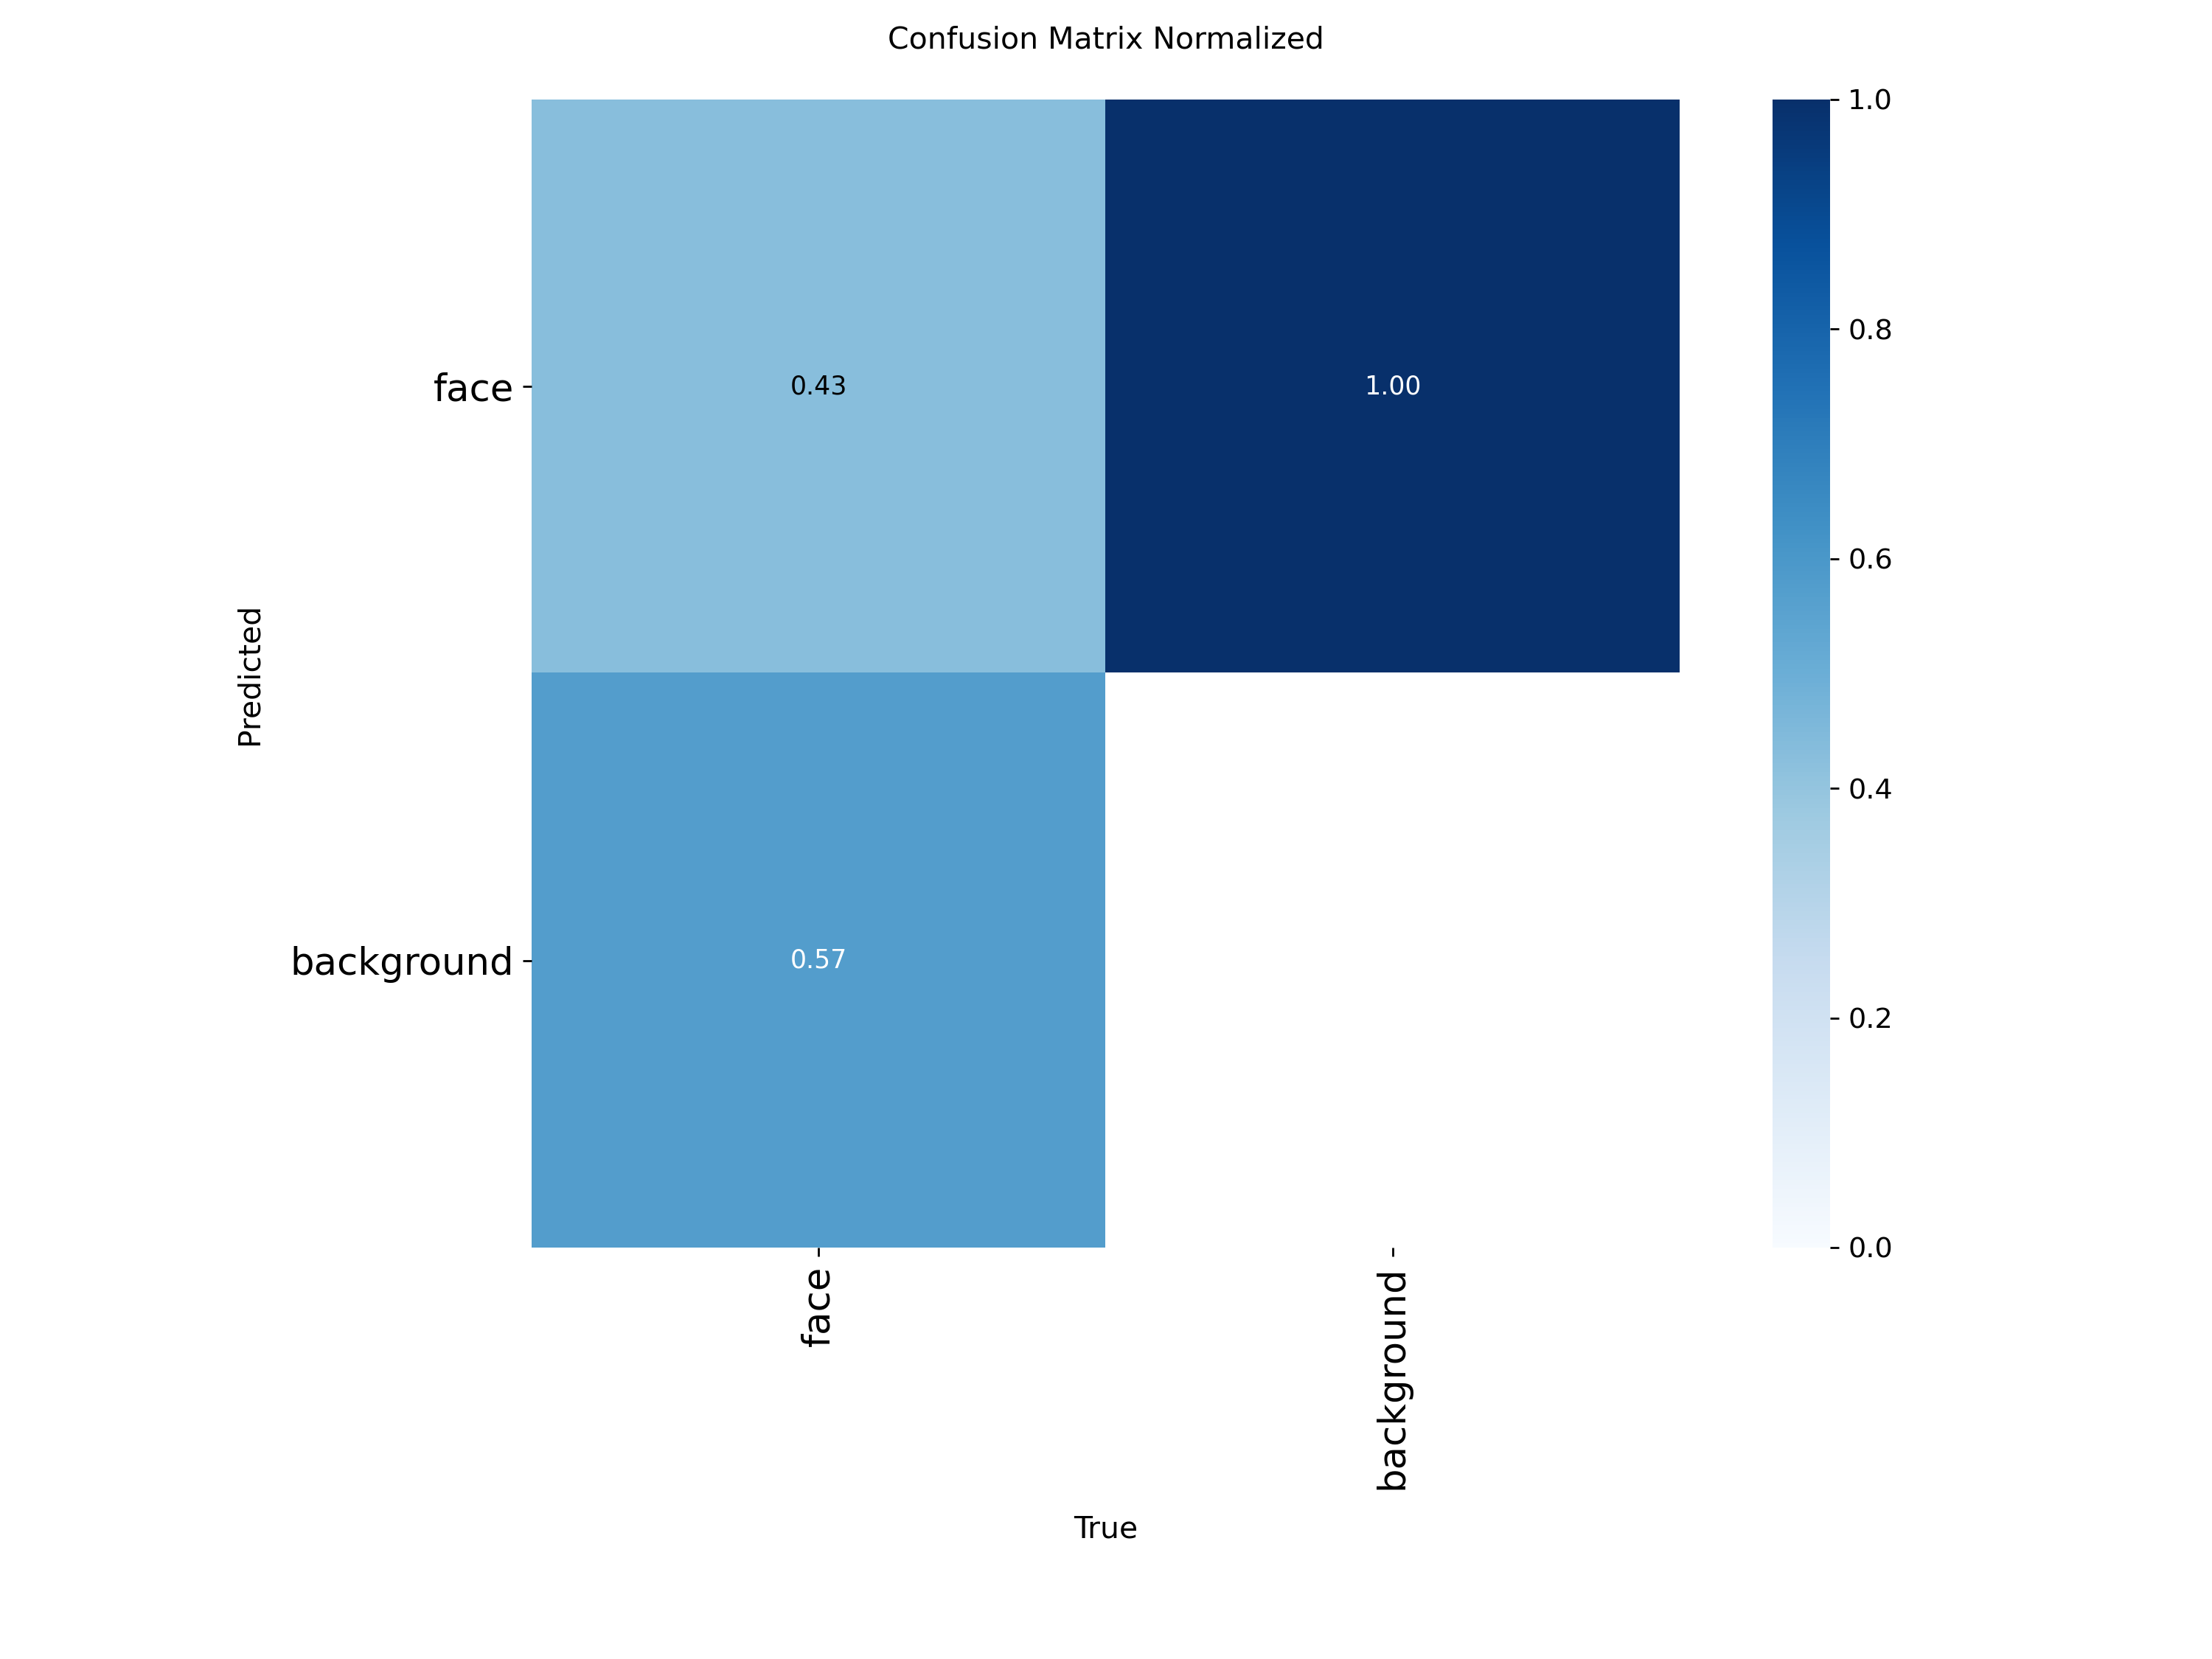

**BoxPR_curve.png**

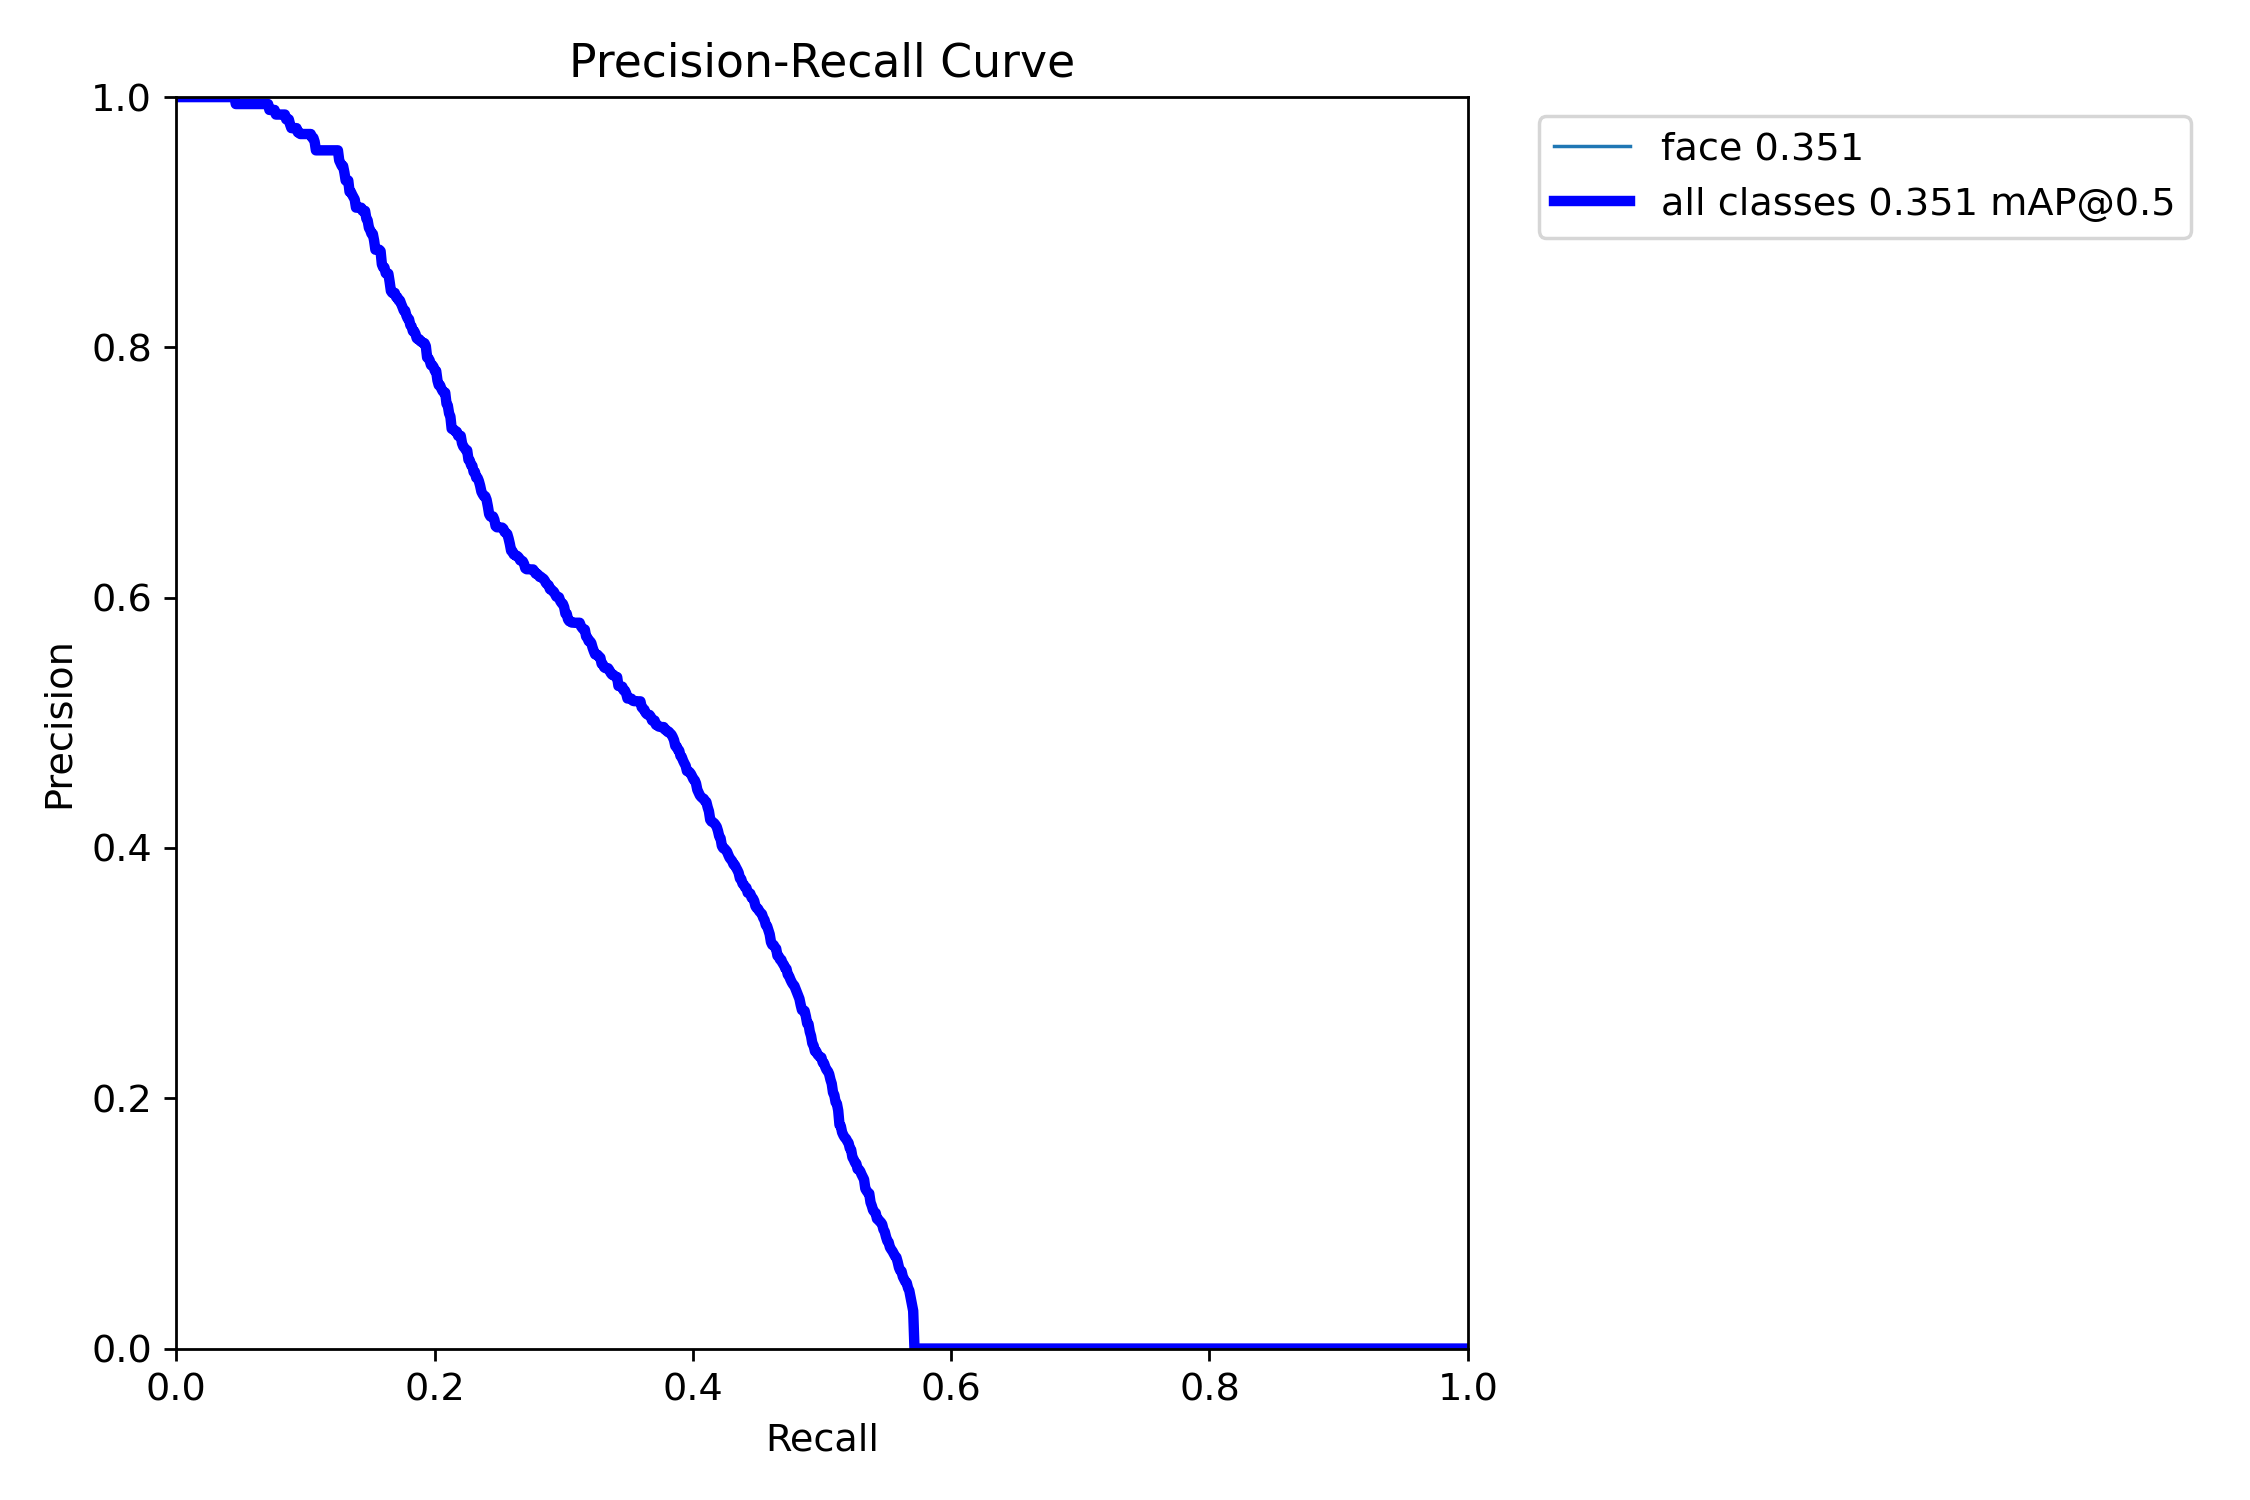

**BoxR_curve.png**

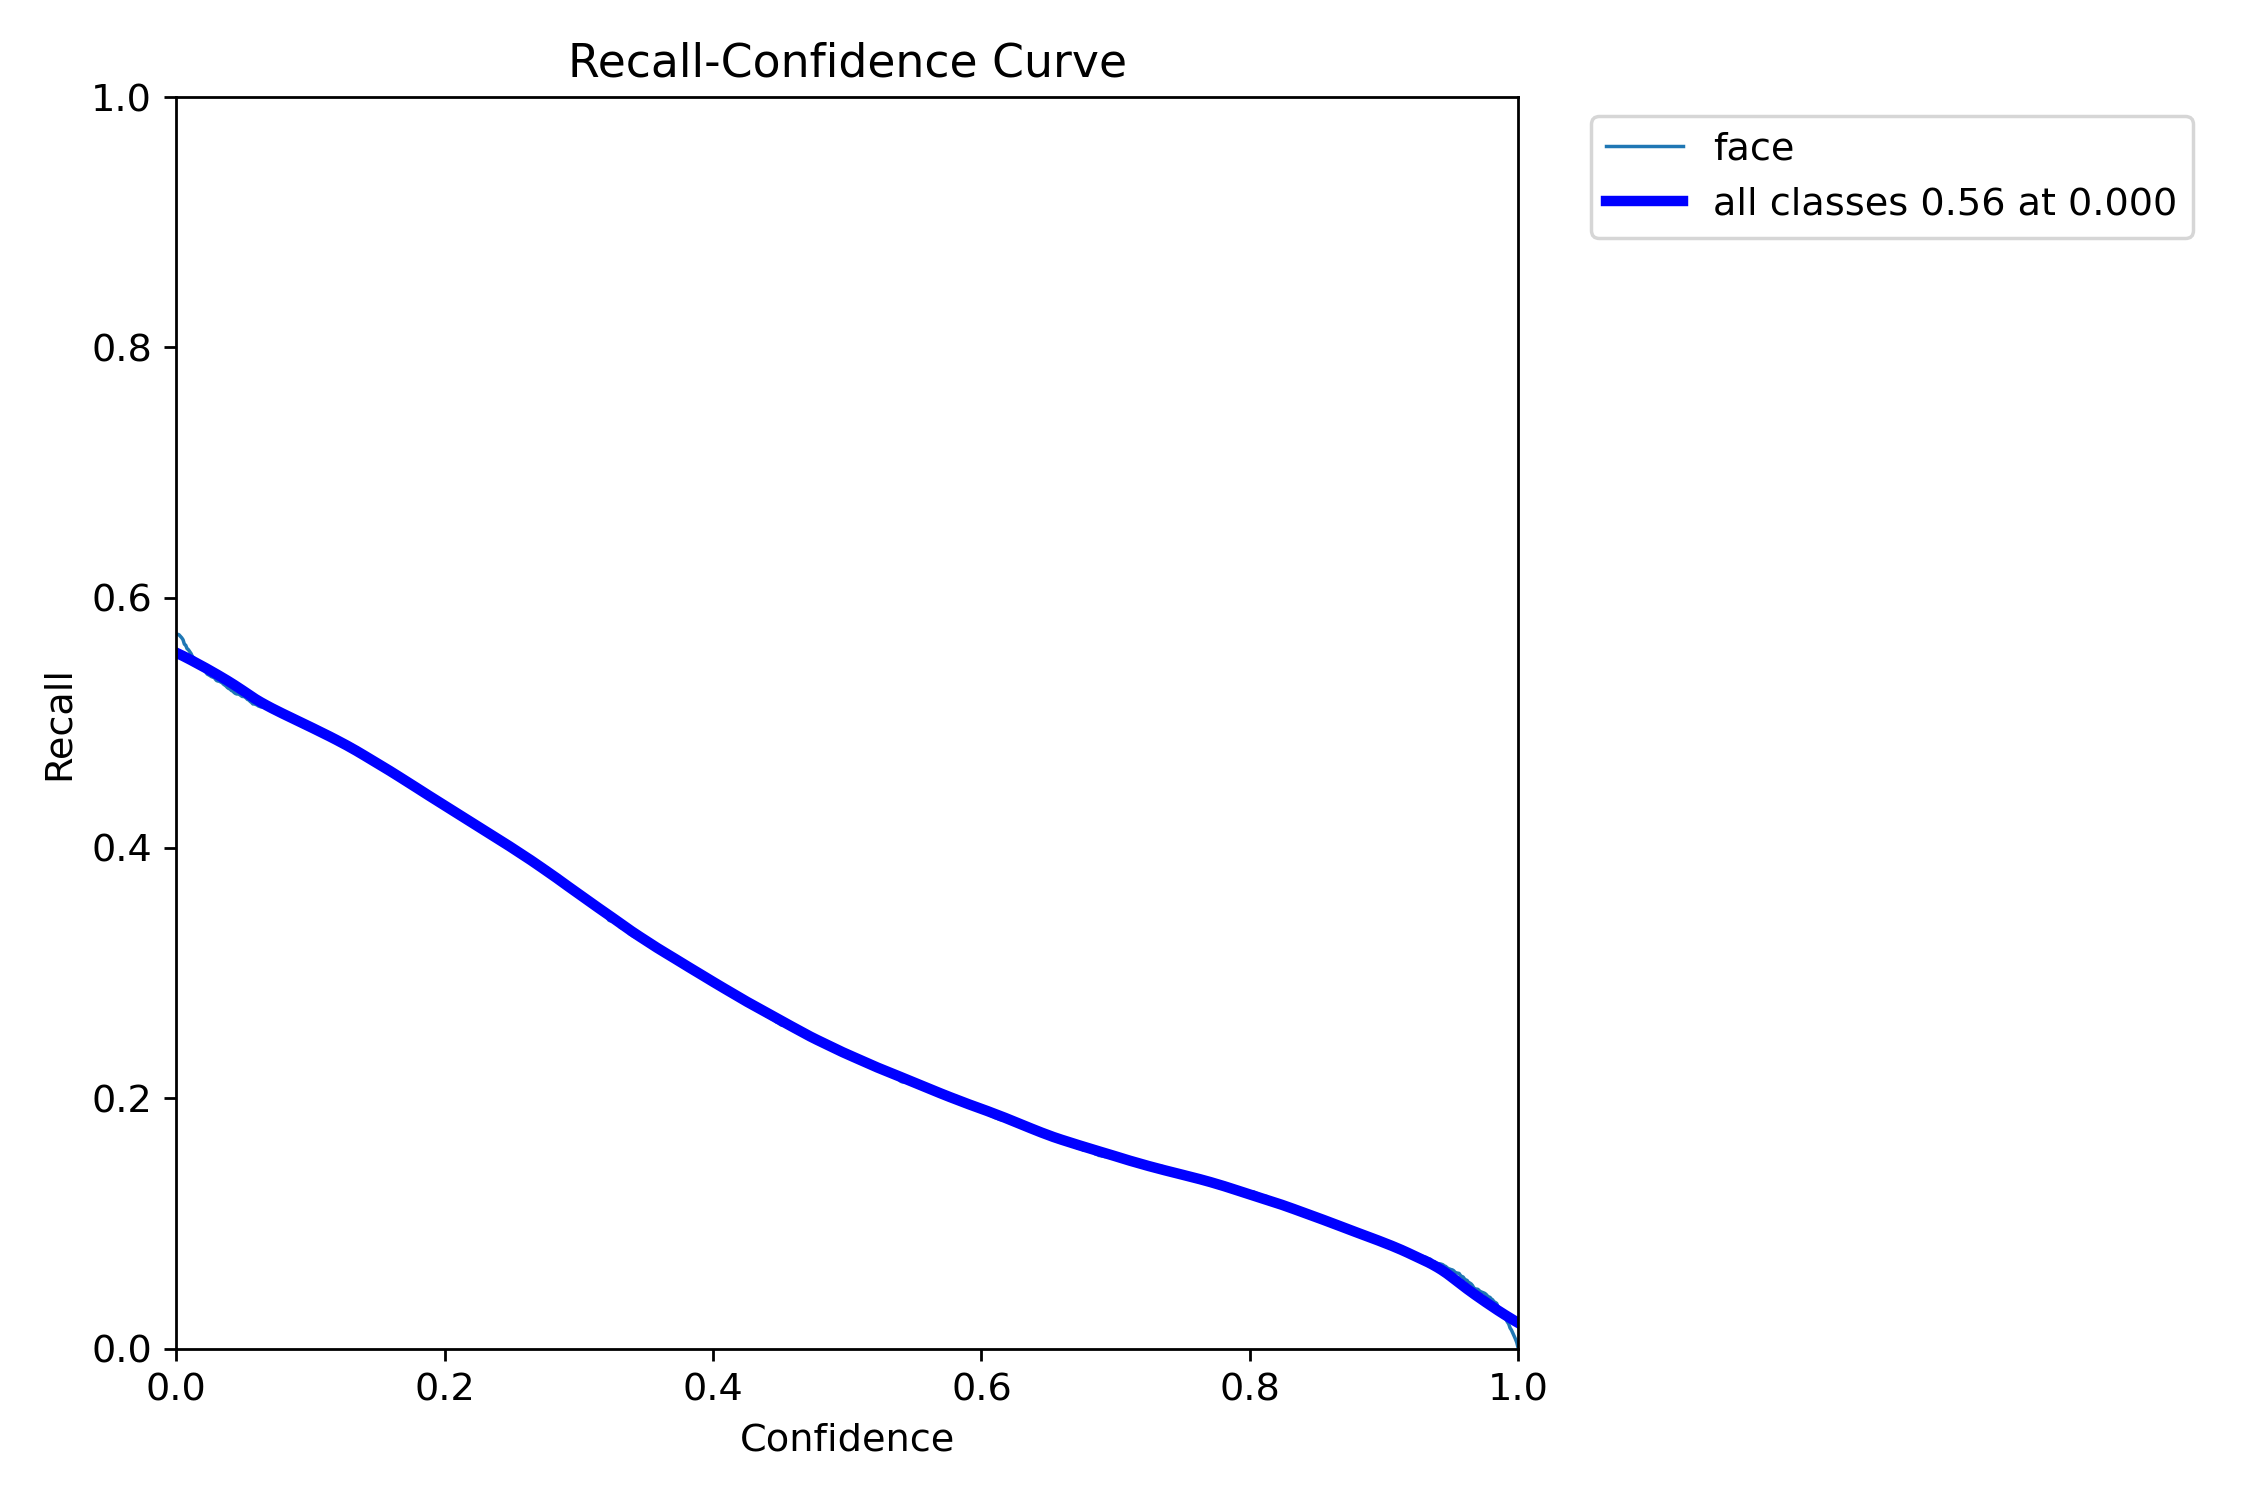

**val_batch0_labels.jpg**

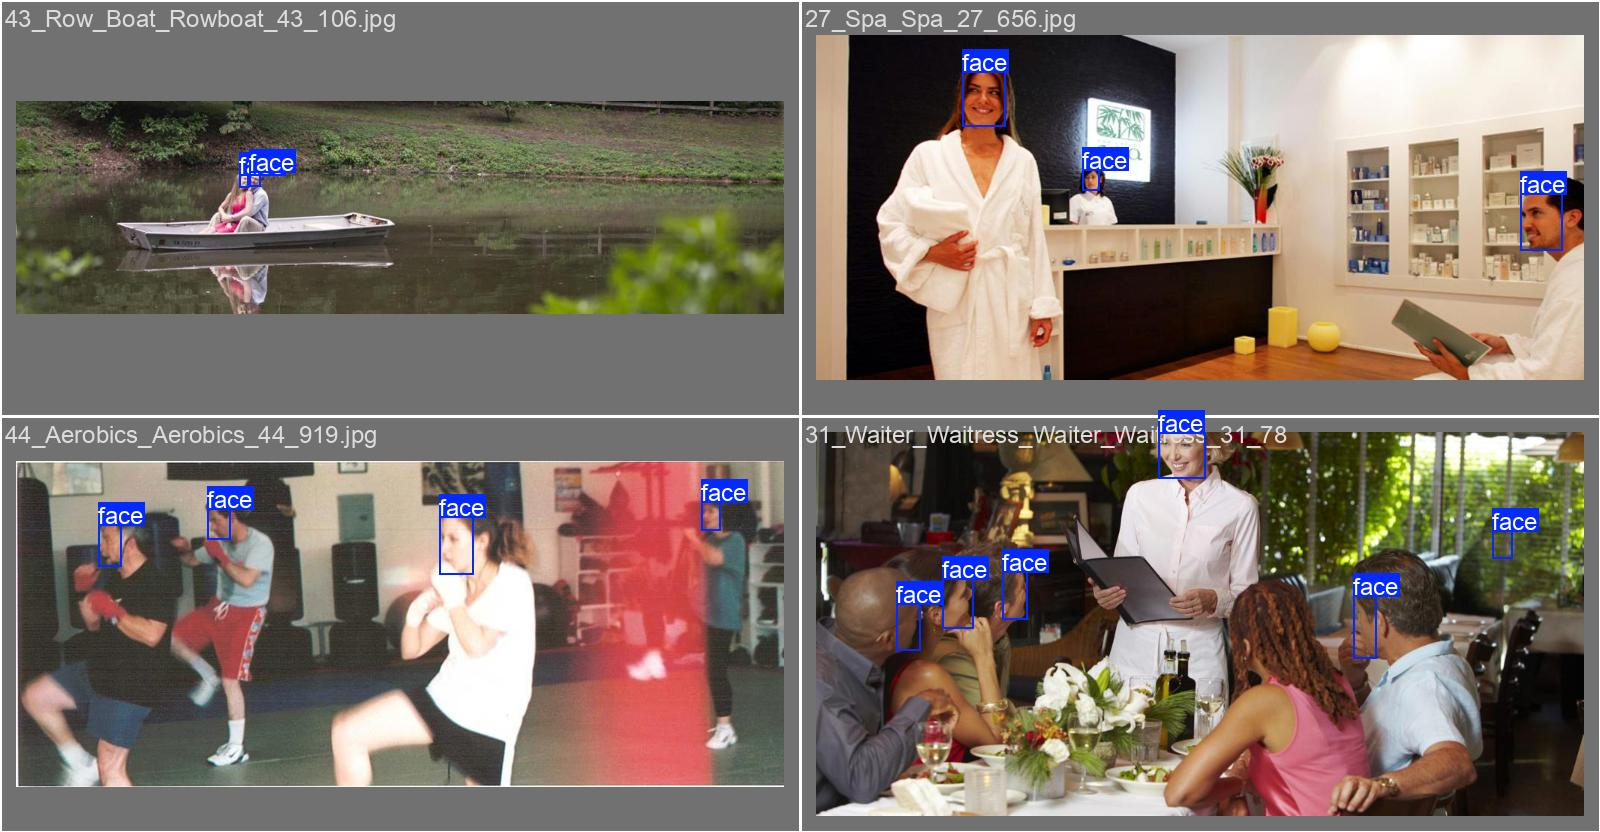

**val_batch0_pred.jpg**

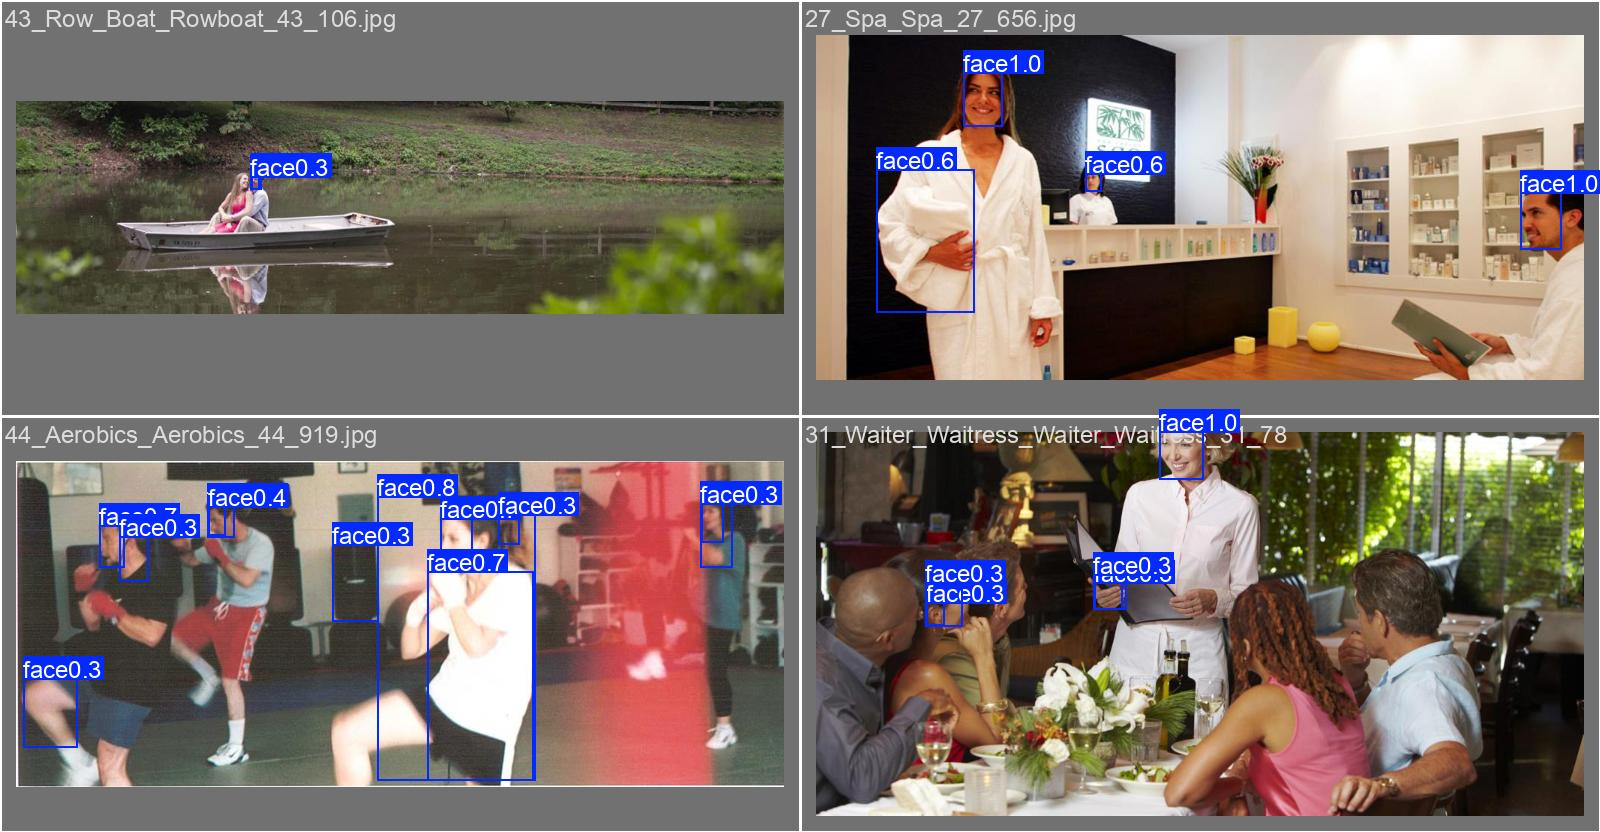

In [7]:
yolo_artifacts = [
    'results.png',
    'confusion_matrix.png',
    'confusion_matrix_normalized.png',
    'BoxPR_curve.png',
    'BoxR_curve.png',
    'val_batch0_labels.jpg',
    'val_batch0_pred.jpg',
]
print('YOLO Run:', yolo_run)
for name in yolo_artifacts:
    path = yolo_run / name
    if path.exists():
        display(Markdown(f'**{name}**'))
        display(Image(filename=str(path)))
    else:
        print('Fehlt:', path)


## Kurzfazit

- **Recall-Sieger im Red20/ep1-Lauf:** FCOS mit ca. 0,547 Recall bei ca. 36 ms/Bild.
- **Starke Praxisoption:** YOLOv8m erreicht ca. 0,406 Recall bei ca. 44 ms/Bild und liefert die beste direkte Anbindung an die Video-Pipeline.
- **COCO-Baselines:** Ohne Face-Finetuning praktisch ungeeignet.
- **Wichtig fuer die Praesentation:** Die Ergebnisse sind ein reproduzierbarer Red20/Batch-2/1-Epoch-Lauf. Fuer ein finales wissenschaftliches Ranking waere ein laengeres, exakt gleiches Training aller Modelle noetig.


## Geblurrte Videos und Blurring-Qualitaet

Die Evaluationszahlen bewerten die Face Detection. Fuer die praktische Anonymisierung ist zusaetzlich wichtig, wie gut der Blur visuell schuetzt und ob Gesichter im Video stabil getroffen werden.


In [8]:
from IPython.display import Video

video_paths = [
    ROOT / 'Videos/lab_outputs/testmaterial_red20_yolo_smoke_blur.mp4',
    ROOT / 'Videos/lab_outputs/anonymisiert_30s_oval_gaussian.mp4',
    ROOT / 'Videos/lab_outputs/anonymisiert_30s_pixelate.mp4',
    ROOT / 'Videos/lab_outputs/vergleich_30s_original_vs_oval_gaussian.mp4',
    ROOT / 'Videos/lab_outputs/vergleich_30s_original_vs_pixelate.mp4',
    ROOT / 'Videos/lab_outputs/testmaterial_red20_yolo_preview_ids.mp4',
    ROOT / 'Videos/lab_outputs/testmaterial_red20_yolo_selected_blur.mp4',
]

lines = ['| Video | Status | Hinweis |', '|---|---|---|']
for path in video_paths:
    status = 'vorhanden' if path.exists() else 'noch nicht erzeugt'
    note = 'selektiver/Preview-Lauf' if 'preview' in path.name or 'selected' in path.name else 'Blur- oder Vergleichsvideo'
    lines.append(f'| `{path.relative_to(ROOT)}` | {status} | {note} |')
display(Markdown('\n'.join(lines)))

for path in video_paths[:3]:
    if path.exists():
        display(Markdown(f'**{path.relative_to(ROOT)}**'))
        display(Video(str(path), embed=False, width=720))


| Video | Status | Hinweis |
|---|---|---|
| `Videos/lab_outputs/testmaterial_red20_yolo_smoke_blur.mp4` | vorhanden | Blur- oder Vergleichsvideo |
| `Videos/lab_outputs/anonymisiert_30s_oval_gaussian.mp4` | vorhanden | Blur- oder Vergleichsvideo |
| `Videos/lab_outputs/anonymisiert_30s_pixelate.mp4` | vorhanden | Blur- oder Vergleichsvideo |
| `Videos/lab_outputs/vergleich_30s_original_vs_oval_gaussian.mp4` | vorhanden | Blur- oder Vergleichsvideo |
| `Videos/lab_outputs/vergleich_30s_original_vs_pixelate.mp4` | vorhanden | Blur- oder Vergleichsvideo |
| `Videos/lab_outputs/testmaterial_red20_yolo_preview_ids.mp4` | vorhanden | selektiver/Preview-Lauf |
| `Videos/lab_outputs/testmaterial_red20_yolo_selected_blur.mp4` | vorhanden | selektiver/Preview-Lauf |

**Videos/lab_outputs/testmaterial_red20_yolo_smoke_blur.mp4**

**Videos/lab_outputs/anonymisiert_30s_oval_gaussian.mp4**

**Videos/lab_outputs/anonymisiert_30s_pixelate.mp4**

### Bewertung der Blurring-Qualitaet

- **Ovaler Gaussian Blur:** Visuell am saubersten fuer Praesentationen, weil die Gesichtsregion weich verdeckt wird und weniger stoerend wirkt als harte Rechtecke. Bei korrekter Detektion ist die Identitaet in der Regel gut verborgen.
- **Pixelate:** Datenschutzwirkung wirkt deutlicher und robuster, ist aber auffaelliger und weniger natuerlich im Video.
- **Selektives Blurring:** Sinnvoll, wenn nur bestimmte Personen anonymisiert werden sollen. Dafuer zuerst das Preview-Video mit IDs/Raengen erzeugen und danach `--target-track-ids`, `--target-ranks` oder `--target-regions` setzen.
- **Grenze der Qualitaet:** Die Blur-Qualitaet haengt direkt an der Detektion. Im Red20/ep1-Lauf erreicht YOLO ca. 0,406 Recall; fuer eine finale Datenschutzfassung sollten Threshold, Trainingsdauer und manuelle Stichprobenpruefung verbessert werden.
- **Aktueller Smoke-Lauf:** `testmaterial_red20_yolo_smoke_blur.mp4` zeigt die Pipeline-Funktion, ist aber wegen kurzer Trainingsdauer und kurzer Videosequenz eher ein technischer Nachweis als ein finaler Datenschutzexport.
